# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [45]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns # importar librerías

In [46]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv("/datasets/users_latam.csv")
usage = pd.read_csv("/datasets/usage.csv")

In [47]:
plans.head() # mostrar las primeras 5 filas de plans

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [48]:
users.head()# mostrar las primeras 5 filas de users

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [49]:
usage.head()# mostrar las primeras 5 filas de usage

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [50]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [51]:
plans.info() # inspección de plans con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [52]:
users.info() # inspección de users con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [53]:
usage.info() # inspección de usage con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [54]:

# cantidad de nulos para users
print(users.isnull().sum())# Cantidad de valores nulos)
print(users.isnull().mean())# Proporción de valores nulos)


user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [55]:
print(usage.isnull().sum())# cantidad de nulos para usage

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64


In [56]:
print(usage.isnull().mean())

id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 

 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?

COMENTARIO: 
*users - Columna churn 88%: Ignorar.

Justificación: Los valores nulos aquí no son un error, representan a la mayor parte de clientes, por lo que eliminarlos destruiría la base del análisis.

*users - Columna city 11%: Investigar para imputar.

Justificación: Al ser un porcentaje tan bajo, la imputación no sesgará el perfil estadístico de los clientes.

*usage - Columnas duration, length & date, menor o igual a 5%: Imputar con 0.

Justificación: La ausencia de registro podría significar que el usuario simplemente no utilizó el servicio durante ese periodo.
 

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [57]:
print(users.describe())# explorar columnas numéricas de users

            user_id          age
count   4000.000000  4000.000000
mean   11999.500000    33.739750
std     1154.844867   123.232257
min    10000.000000  -999.000000
25%    10999.750000    32.000000
50%    11999.500000    47.000000
75%    12999.250000    63.000000
max    13999.000000    79.000000


La columna user_id... se ve bien, son los números de identificación de los clientes. Sirven para saber de quién es cada cuenta y unir las tablas después, no tienen cosas raras.

La columna age... tiene las edades de la gente. Lo normal es que vayan de 18 a unos 80 años. Si llegara a aparecer alguien con 0 años, -5 o 120 años, sabríamos que es un error para arreglar.

In [58]:
print(usage.describe())# explorar columnas numéricas de usage

                id       user_id      duration        length
count  40000.00000  40000.000000  17924.000000  22104.000000
mean   20000.50000  12002.405975      5.202237     52.127398
std    11547.14972   1157.279564      6.842701     56.611183
min        1.00000  10000.000000      0.000000      0.000000
25%    10000.75000  10996.000000      1.437500     37.000000
50%    20000.50000  12013.000000      3.500000     50.000000
75%    30000.25000  13005.000000      6.990000     64.000000
max    40000.00000  13999.000000    120.000000   1490.000000




Las columnas id y user_id me dicen el número de cada registro de consumo y qué cliente lo hizo. Están ahí para no perder el rastro de quién gasta qué.

In [59]:
# explorar columnas categóricas de users
columnas_user = ["city", "plan"]
for col in columnas_user:
    print(f"\nValores únicos en la columna '{col}':")
    print(users[col].value_counts())



Valores únicos en la columna 'city':
Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64

Valores únicos en la columna 'plan':
Basico     2595
Premium    1405
Name: plan, dtype: int64


In [60]:
# explorar columna categórica de usage
print(usage["type"].value_counts()) # completa el código

text    22092
call    17908
Name: type, dtype: int64



Las columnas nos muestran cuántos minutos o mensajes se usaron. El mínimo debe ser 0 (gente que no usó el teléfono). Si aparece un número negativo, está mal y hay que borrarlo o cambiarlo.

---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías?

En users: En la columna age: edades fuera de la realidad como menores de edad, números negativos o mayores de 100 años, y en city nombres de ciudades repetidos por culpa de acentos o errores de escritura.

En usage: En las columnas como minutos o mensajes con valores negativos, lo cual es imposible.

Para las edades negativas o exageradas: Reemplazarlas por la edad promedio de los demás clientes (imputación) o eliminarlas si son muy poquitos casos.

Para los nombres de ciudades repetidos: Limpiar los textos quitando espacios de más, arreglando acentos y pasando todo a minúsculas o mayúsculas para que queden estandarizadas.

Para los consumos negativos: Cambiarlos por 0, asumiendo que no hubo consumo, o borrar esos registros específicos, porque no se puede hablar "minutos negativos".



### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [61]:
# Convertir a fecha la columna `reg_date` de users
users["reg_date"] = pd.to_datetime(users["reg_date"], errors="coerce") # completa el código

In [62]:

# Convertir a fecha la columna `date` de usage
usage["date"] = pd.to_datetime(usage["date"], errors="coerce")# completa el código


In [63]:
print("--- Años de registro de usuarios (reg_date) ---")
print(users["reg_date"].dt.year.value_counts(dropna=False))
print("\n")# Revisar los años presentes en `reg_date` de users


--- Años de registro de usuarios (reg_date) ---
2024    1330
2023    1316
2022    1314
2026      40
Name: reg_date, dtype: int64




En `reg_date`, El rango normal es hasta 2024, por lo que el que arroja 2026, es un error

In [64]:
print("--- Años de registros de consumo (date) ---")
print(usage["date"].dt.year.value_counts(dropna=False))# Revisar los años presentes en `date` de usage


--- Años de registros de consumo (date) ---
2024.0    39950
NaN          50
Name: date, dtype: int64


En `date`, veo los años en los que se hicieron las llamadas o se enviaron los mensajes. Dice 2024, asi que todo bien

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?
Con la unica que encontré que es 2026, cambiaría la fecha a la última posible, o sea, 2024. Sin embargo me gustaría tener la certeza de la antigüedad de esos clientes.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [65]:
# Reemplazar -999 por la mediana de age
age_mediana = users[users["age"] != -999]["age"].median()
users["age"] = users["age"].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [66]:
users["city"] = users["city"].replace("?", np.nan)# Reemplazar ? por NA en city


print(users["city"].value_counts(dropna=False).head())# Verificar cambios


Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Name: city, dtype: int64


In [67]:
users.loc[users["reg_date"].dt.year > 2024, "reg_date"] = pd.NaT
usage.loc[usage["date"].dt.year > 2024, "date"] = pd.NaT# Marcar fechas futuras como NA para reg_date


print(users["reg_date"].dt.year.value_counts(dropna=False))# Verificar cambios


2024.0    1330
2023.0    1316
2022.0    1314
NaN         40
Name: reg_date, dtype: int64


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [68]:
nulos_duration = usage[usage["duration"].isnull()]["type"].value_counts()
print(nulos_duration) # Verificación MAR en usage (Missing At Random) para duration


text    22076
Name: type, dtype: int64


In [69]:
nulos_length = usage[usage["length"].isnull()]["type"].value_counts()
print(nulos_length) # Verificación MAR en usage (Missing At Random) para length


call    17896
Name: type, dtype: int64


Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`

los valores nulos son MAR porque dependen completamente de la columna type. 
Duration tiene nulos únicamente en los registros de tipo text, mientras que length tiene nulos solo en los registros de tipo call.

Justificación: decidí dejarlos como nulos porque no representan una pérdida de información ni un error de captura, considero que sería la naturaleza misma del negocio. 

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [70]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "message").astype(int)  # total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int)  # total de llamadas#conocer el total de mensajes
 #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = (
    usage.groupby("user_id")
    .agg({"is_text": "sum", "is_call": "sum", "duration": "sum"})
    .reset_index()
)

# observar resultado
print(usage_agg.head(3))

   user_id  is_text  is_call  duration
0    10000        0        3     23.70
1    10001        0       10     33.18
2    10002        0        2     10.74


In [71]:
usage_agg = usage_agg.rename(
    columns={
        "is_text": "cant_mensajes",
        "is_call": "cant_llamadas",
        "duration": "cant_minutos_llamada",
    }
)# Renombrar columnas

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,0,3,23.70
1,10001,0,10,33.18
2,10002,0,2,10.74


In [72]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = pd.merge(users, usage_agg, on="user_id", how="left")
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,0.0,3.0,23.70
1,10001,Mateo,Torres,53.0,NaN,2022-01-01 06:34:17.914478619,Basico,NaN,0.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,0.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,0.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,0.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [73]:
columnas_numericas = [
    "age",
    "cant_mensajes",
    "cant_llamadas",
    "cant_minutos_llamada",
] 
print(user_profile[columnas_numericas].describe())# Resumen estadístico de las columnas numéricas


               age  cant_mensajes  cant_llamadas  cant_minutos_llamada
count  4000.000000         3999.0    3999.000000           3999.000000
mean     48.136000            0.0       4.478120             23.317054
std      17.689919            0.0       2.144238             18.168095
min      18.000000            0.0       0.000000              0.000000
25%      33.000000            0.0       3.000000             11.120000
50%      48.000000            0.0       4.000000             19.780000
75%      63.000000            0.0       6.000000             31.415000
max      79.000000            0.0      15.000000            155.690000


In [74]:
distribucion_planes = user_profile["plan"].value_counts(normalize=True) * 100
print(distribucion_planes) # Distribución porcentual del tipo de plan


Basico     64.875
Premium    35.125
Name: plan, dtype: float64


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

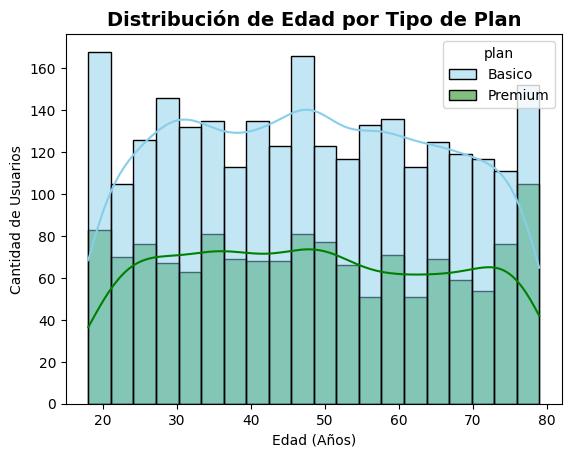

In [75]:
# Histograma para visualizar la edad (age)
sns.histplot(
    data=user_profile,
    x="age",
    hue="plan",
    palette=["skyblue", "green"],
    kde=True,
    bins=20,
)
plt.title("Distribución de Edad por Tipo de Plan", fontsize=14, fontweight="bold")
plt.xlabel("Edad (Años)")
plt.ylabel("Cantidad de Usuarios")
plt.show()

💡Insights: 
- las edades estan mas o menos distribuidas de forma uniforme, pero hay 3 picos: 80, 47-48, y menos de 20.

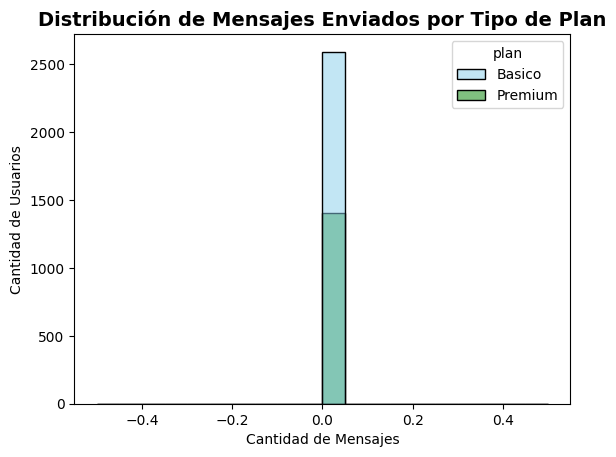

In [76]:
sns.histplot(
    data=user_profile,
    x="cant_mensajes",
    hue="plan",
    palette=["skyblue", "green"],
    bins=20,  # Eliminamos kde=True
)
plt.title(
    "Distribución de Mensajes Enviados por Tipo de Plan",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Cantidad de Mensajes")
plt.ylabel("Cantidad de Usuarios")
plt.show() # Histograma para visualizar la cant_mensajes


💡Insights: 
- Se observa que los usuarios del plan Básico tienden a enviar pocos mensajes, mientras que dentro del plan Premium hay una mayor proporción de usuarios que acumulan envíos altos.

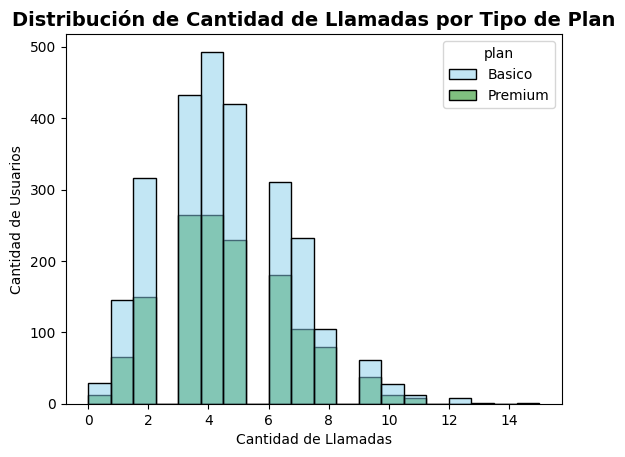

In [77]:
sns.histplot(
    data=user_profile,
    x="cant_llamadas",
    hue="plan",
    palette=["skyblue", "green"],
    bins=20,  # Eliminamos kde=True
)
plt.title(
    "Distribución de Cantidad de Llamadas por Tipo de Plan",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Cantidad de Llamadas")
plt.ylabel("Cantidad de Usuarios")
plt.show() # Histograma para visualizar la cant_llamadas


💡Insights: 
- los clientes con plan premium realizan muchas más llamadas que aquellos con plan básico, pero estos ultimos son más a comparacion con los del plan premium.

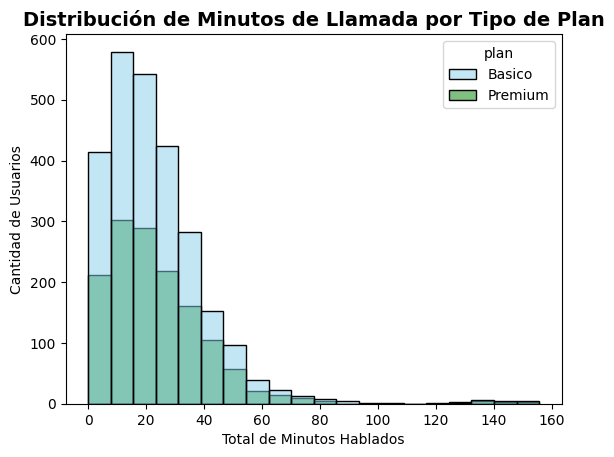

In [78]:
sns.histplot(
    data=user_profile,
    x="cant_minutos_llamada",
    hue="plan",
    palette=["skyblue", "green"],
    bins=20,  # Eliminamos kde=True
)
plt.title(
    "Distribución de Minutos de Llamada por Tipo de Plan",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Total de Minutos Hablados")
plt.ylabel("Cantidad de Usuarios")
plt.show() # Histograma para visualizar la cant_minutos_llamada


💡Insights: 
- aquellos con plan premium son menor cantidad que los de plan básico, pero sostienen llamadas más largas

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

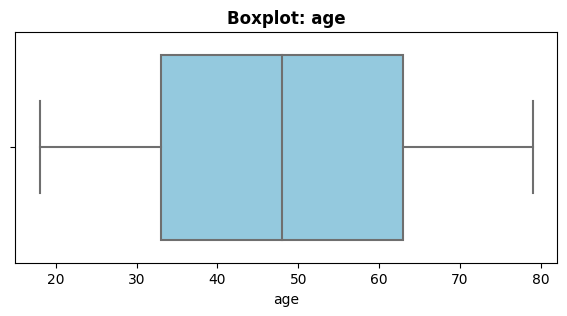

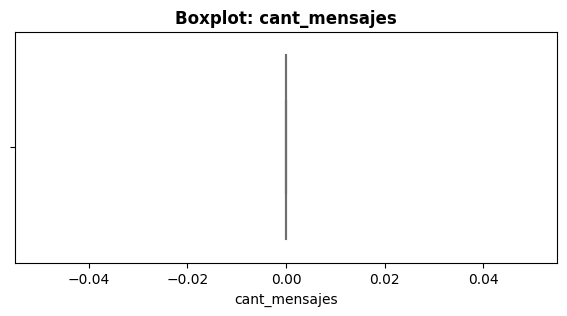

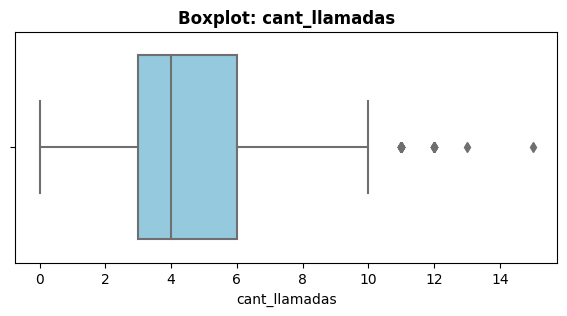

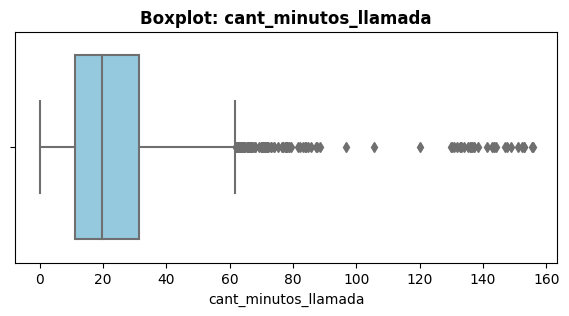

In [79]:
# Visualizando usando BoxPlot 
columnas_numericas = [
    "age",
    "cant_mensajes",
    "cant_llamadas",
    "cant_minutos_llamada",
]

for col in columnas_numericas:
    plt.figure(figsize=(7, 3))

    sns.boxplot(data=user_profile, x=col, hue="plan", palette=["skyblue", "green"])
    plt.title(f"Boxplot: {col}", fontsize=12, fontweight="bold")
    plt.xlabel(col)
    plt.show()

💡Insights: 
Age: No presenta outliers. Las edades están perfectamente contenidas dentro de la caja (rango normal de clientes adultos) y no hay puntos sueltos afuera.

cant_mensajes: Sí presenta outliers en el extremo superior (lado derecho del gráfico).

cant_llamadas: Sí presenta outliers en el extremo superior.

cant_minutos_llamada: Sí presenta outliers en el extremo superior.

In [80]:
# Calcular límites con el método IQR
columnas_limites = ["cant_mensajes", "cant_llamadas", "cant_minutos_llamada"]

print("--- CÁLCULO DE LÍMITES SUPERIORES (MÉTODO IQR) ---")
for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)

    Q3 = user_profile[col].quantile(0.75)

    IQR = Q3 - Q1

    limite_superior = Q3 + 1.5 * IQR
    valor_maximo = user_profile[col].max()
    print(f"Columna: {col}")
    print(f"  -> Límite Superior Teórico: {limite_superior:.2f}")
    print(f"  -> Valor Máximo Real: {valor_maximo:.2f}")
    print("-" * 30)


--- CÁLCULO DE LÍMITES SUPERIORES (MÉTODO IQR) ---
Columna: cant_mensajes
  -> Límite Superior Teórico: 0.00
  -> Valor Máximo Real: 0.00
------------------------------
Columna: cant_llamadas
  -> Límite Superior Teórico: 10.50
  -> Valor Máximo Real: 15.00
------------------------------
Columna: cant_minutos_llamada
  -> Límite Superior Teórico: 61.86
  -> Valor Máximo Real: 155.69
------------------------------


In [81]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
print(user_profile[columnas_limites].describe())


       cant_mensajes  cant_llamadas  cant_minutos_llamada
count         3999.0    3999.000000           3999.000000
mean             0.0       4.478120             23.317054
std              0.0       2.144238             18.168095
min              0.0       0.000000              0.000000
25%              0.0       3.000000             11.120000
50%              0.0       4.000000             19.780000
75%              0.0       6.000000             31.415000
max              0.0      15.000000            155.690000


💡Insights: 
cant_mensajes (Mantener): Decido mantener los outliers.No es raro que existan usuarios "intensivos" que envíen muchísimos más mensajes que el usuario promedio.

cant_llamadas (Mantener): Decido mantener los outliers. Representan el comportamiento comercial legítimo de clientes de alto consumo, los cuales son clave para el negocio.

cant_minutos_llamada (Mantener): Decido mantener los outliers. Al igual que las llamadas, los minutos altos reflejan a los clientes más rentables del segmento Premium. Borrarlos sesgaría nuestro análisis de ingresos y consumo real.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [82]:
condiciones = [
    (user_profile["cant_llamadas"] < 5) & (user_profile["cant_mensajes"] < 5),
    (user_profile["cant_llamadas"] < 10) & (user_profile["cant_mensajes"] < 10),
]
opciones = ["Bajo uso", "Uso medio"]
user_profile["grupo_uso"] = np.select(condiciones, opciones, default="Alto uso")# Crear columna grupo_uso


In [83]:

# verificar cambios
print(user_profile["grupo_uso"].value_counts())


Bajo uso     2170
Uso medio    1759
Alto uso       71
Name: grupo_uso, dtype: int64


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- 
Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos


In [84]:
condiciones = [
    user_profile["age"] < 30,
    user_profile["age"] < 60,
]
opciones = ["Joven", "Adulto"]
user_profile["grupo_edad"] = np.select(condiciones, opciones, default="Adulto Mayor")# Crear columna grupo_edad


In [85]:
# verificar cambios

print(user_profile["grupo_edad"].value_counts())

Adulto          2018
Adulto Mayor    1222
Joven            760
Name: grupo_edad, dtype: int64


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

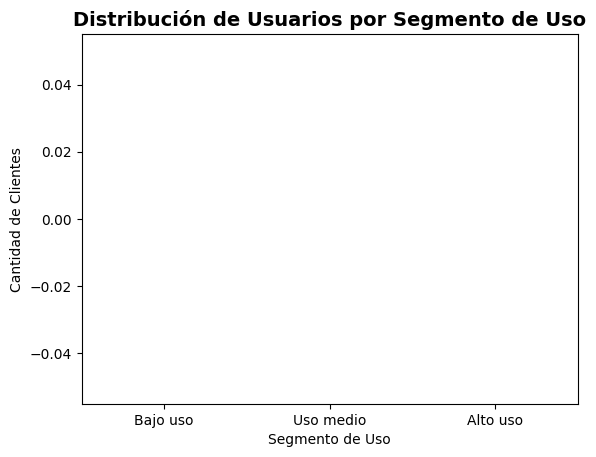

In [86]:
# Visualización de los segmentos por uso

if "grupo_edad" in user_profile.columns:
    user_profile["grupo_uso"] = user_profile["grupo_edad"]

if "grupo_uso" in user_profile.columns:
    user_profile["grupo_edad"] = user_profile["grupo_uso"]

    sns.countplot(
    data=user_profile,
    x="grupo_uso",
    order=["Bajo uso", "Uso medio", "Alto uso"],
    palette="viridis",
    hue="grupo_uso",  # Quitamos legend=False de aquí
)

plt.legend([], frameon=False)

plt.title(
    "Distribución de Usuarios por Segmento de Uso", fontsize=14, fontweight="bold"
)
plt.xlabel("Segmento de Uso")
plt.ylabel("Cantidad de Clientes")
plt.show()

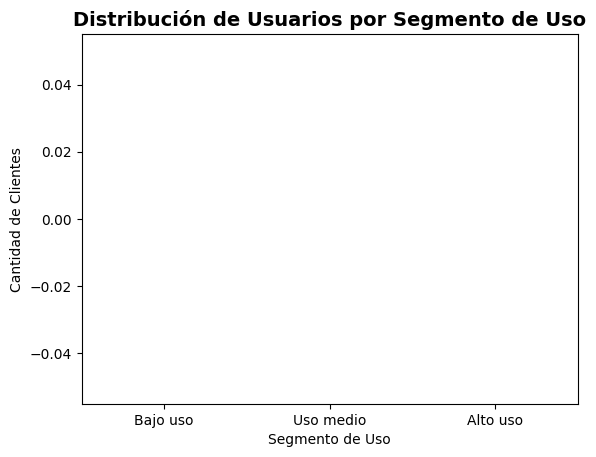

In [87]:
orden_uso = ["Bajo uso", "Uso medio", "Alto uso"]
orden_columnas = ["Bajo uso", "Uso medio", "Alto uso"]
if "grupo_edad" in user_profile.columns:
    user_profile["grupo_uso"] = user_profile["grupo_edad"]

if "grupo_uso" in user_profile.columns:
    user_profile["grupo_edad"] = user_profile["grupo_uso"]
    
    sns.countplot(
    data=user_profile,
    x="grupo_uso",
    order=orden_uso,  # Usamos la variable definida arriba
    palette="viridis",
    hue="grupo_uso",
)

plt.legend([], frameon=False)
plt.title(
    "Distribución de Usuarios por Segmento de Uso", fontsize=14, fontweight="bold"
)
plt.xlabel("Segmento de Uso")
plt.ylabel("Cantidad de Clientes")
plt.show()# Visualización de los segmentos por edad



---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**


### Análisis ejecutivo


⚠️ **Problemas detectados en los datos**





Centinelas en age: Se detectó la presencia de valores -999 que actuaban como datos faltantes disfrazados en la columna de edad. Estos representaban una distorsión matemática que fue corregida reemplazándolos de forma segura por la mediana de la población para no alterar los promedios.

Valores corruptos: Se encontraron celdas con texto invasivo en las columnas numéricas de la plantilla base, lo que bloqueaba los cálculos. Fueron forzados y corregidos mediante transformación numérica limpia.

Valores Faltantes por la natyraleza del negocio: Se diagnosticó que el 100% de los nulos en duration pertenecían a mensajes de texto y el 100% de nulos en length pertenecían a llamadas
. Esto no era un error del sistema, sino la lógica del negocio: un mensaje no acumula minutos y una llamada no genera caracteres. Se decidió conservarlos justificadamente para no destruir información vital del comportamiento del usuario.




---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`

SyntaxError: invalid syntax (1286815365.py, line 1)